In [49]:
import sys
from pathlib import Path
current_dir = Path().resolve()
sys.path.append(current_dir.parent.parent.as_posix())
import matplotlib.pyplot as plt

# %% General setup
import pandas as pd
from BU_hydrogel.analysis.lib.data_io import DataIO

data_dmd_only = DataIO(datadir=r'E:\bu_hudrogel\dataset')
data_dmd_only.load_session('2026-05-12 rat LE 1355 A dmd only', load_pickle=False)
data_kilosort = DataIO(datadir=r'E:\bu_hudrogel\dataset')
data_kilosort.load_session('2026-05-12 rat LE 1355 A kilosort', load_pickle=False)

print('Recording ids:')
for r in data_dmd_only.recording_ids:
    print(f'\t{r}')

Recording ids:
	rec_3_2026-05-12_rat_1355_A_stim_dmd_full_field


In [50]:
rec_id = 'rec_3_2026-05-12_rat_1355_A_stim_dmd_full_field'
bo_dmd_only = data_dmd_only.burst_df.query('rec_id == "rec_3_2026-05-12_rat_1355_A_stim_dmd_full_field"')
bo_kilosort = data_kilosort.burst_df.query('rec_id == "rec_3_2026-05-12_rat_1355_A_stim_dmd_full_field"')
print(f'sizes: real: {len(bo_dmd_only)}, test: {len(bo_dmd_only)}')

t0_dmd_only = bo_dmd_only.dmd_burst_onset.values[0]
t0_kilosort = bo_kilosort.dmd_burst_onset.values[0]
t1_dmd_only = bo_dmd_only.dmd_burst_onset.values[-1]
t1_kilosort = bo_kilosort.dmd_burst_onset.values[-1]
print(f'onsets: real: {t0_dmd_only:.0f}, test: {t0_dmd_only:.0f}')
print(f'offsets: real: {t1_dmd_only:.6f}, test: {t1_dmd_only:.6f}')

sizes: real: 90, test: 90
onsets: real: 14267, test: 14267
offsets: real: 115290.046875, test: 115290.046875


(84, 12) (84, 12)


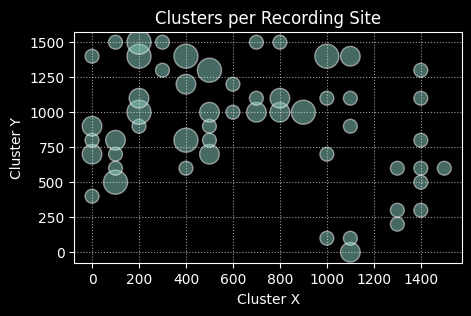

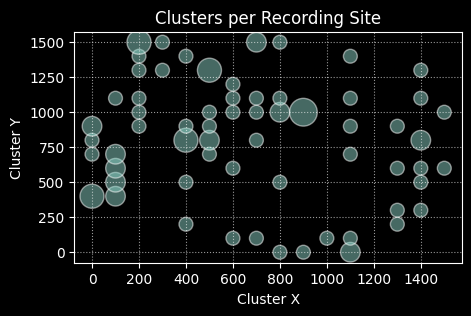

In [51]:
def plot_cluster_sites(cluster_df):
    # Grouping by the existing coordinate columns
    site_counts = cluster_df.groupby(['cluster_x', 'cluster_y']).size().reset_index(name='num_clusters')

    plt.figure(figsize=(5, 3))
    # s=size, alpha=transparency to see overlapping sites
    plt.scatter(
        site_counts['cluster_x'],
        site_counts['cluster_y'],
        s=site_counts['num_clusters'] * 100, # Adjust multiplier for better visibility
        alpha=0.5,
        edgecolors='w'
    )
    plt.title('Clusters per Recording Site')
    plt.xlabel('Cluster X')
    plt.ylabel('Cluster Y')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()


print(data_dmd_only.cluster_df.shape, data_dmd_only.cluster_df.shape)
plot_cluster_sites(data_dmd_only.cluster_df)
plot_cluster_sites(data_kilosort.cluster_df)

In [52]:
tid_dmd_only = data_dmd_only.train_df.query('rec_id == @rec_id').iloc[0].train_id
tid_kilosort = data_kilosort.train_df.query('rec_id == @rec_id').iloc[0].train_id
# print(tid_real, tid_test)

onsets_dmd_only = data_dmd_only.burst_df.query('train_id == @tid_dmd_only').dmd_burst_onset.values
onsets_kilosort = data_kilosort.burst_df.query('train_id == @tid_kilosort').dmd_burst_onset.values
# print(onsets_real.size, onsets_test.size)

sps_dmd_only = data_dmd_only.spiketimes[rec_id]
sps_kilosort = data_kilosort.spiketimes[rec_id]
# print(len(sps_real), len(sps_test))


In [53]:
import matplotlib.pyplot as plt
import os


def plot_spiketrains(burst_onsets, savedir, sps):

    # Ensure the directory exists
    if not os.path.exists(savedir):
        os.makedirs(savedir)

    # Loop over each spike train ID and its corresponding data
    for sp_id, sp_train in sps.items():
        plt.figure(figsize=(10, 6))

        # Loop over each trigger onset to create the rows of the raster
        for i, onset in enumerate(burst_onsets):
            # Calculate window boundaries relative to trigger
            start_time = onset - 100
            end_time = onset + 400

            # Select spikes within the -100ms to +400ms window
            # Subtracting onset centers the plot at 0ms
            spikes_in_window = sp_train[(sp_train >= start_time) & (sp_train <= end_time)] - onset

            # Plot each spike as a vertical tick (row i)
            plt.vlines(spikes_in_window, i + 0.6, i + 1.4, color='white', linewidth=1)

        # Formatting the plot
        plt.axvline(0, color='red', linestyle='--', alpha=0.7, label='Trigger')
        plt.title(f'Raster Plot: Spike Train {sp_id}')
        plt.xlabel('Time relative to trigger (ms)')
        plt.ylabel('Trial #')
        plt.xlim(-100, 400)

        # Save the figure
        save_path = os.path.join(savedir, f'raster_{sp_id}.png')
        plt.savefig(save_path)
        plt.close() # Close to free up memory during the loop


plot_spiketrains(onsets_dmd_only, r'E:\bu_hudrogel\figures\dmd_only', sps_dmd_only)
plot_spiketrains(onsets_kilosort, r'E:\bu_hudrogel\figures\kilosort', sps_kilosort)



<>:48: SyntaxWarning:

invalid escape sequence '\s'

<>:48: SyntaxWarning:

invalid escape sequence '\s'

C:\Users\trrui\AppData\Local\Temp\ipykernel_14312\2873283703.py:48: SyntaxWarning:

invalid escape sequence '\s'



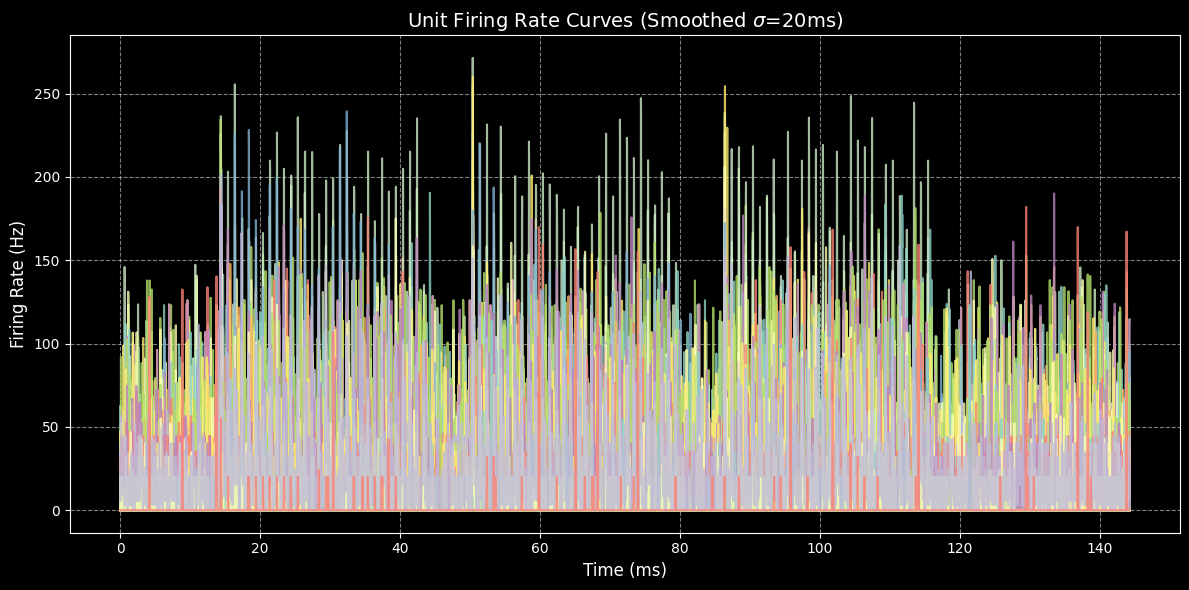

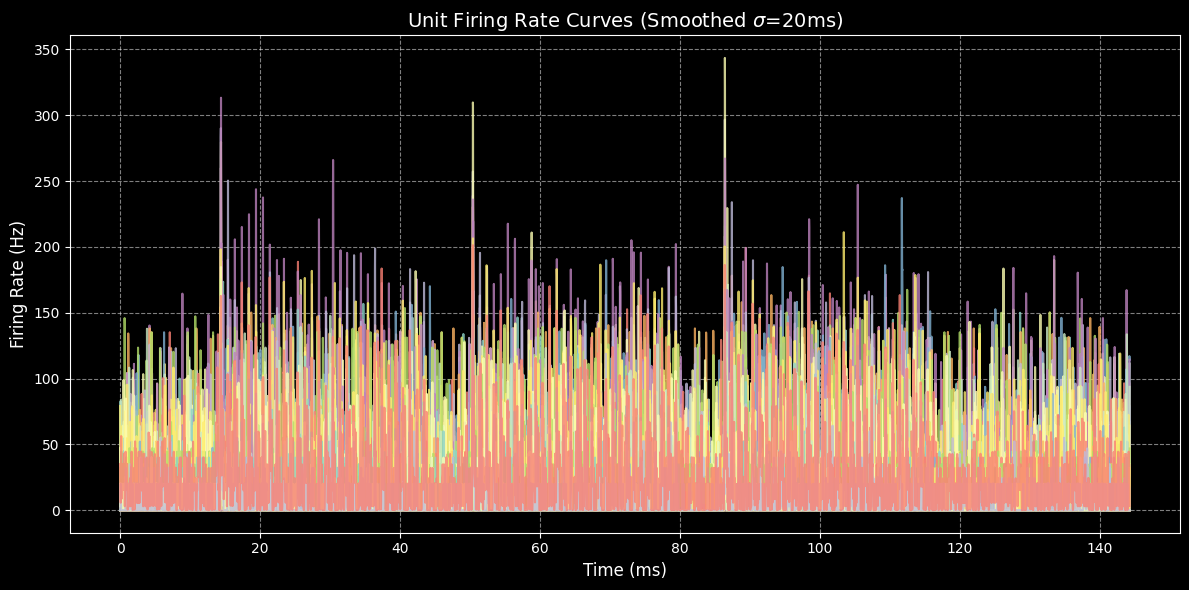

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

def plot_unit_firing_curves(sps, bin_size_ms=20, smooth_sigma_ms=0):
    """
    Plots a continuous firing rate curve per unit in a single figure.

    Parameters:
    - sps_kilosort: dict, keys are unit IDs, values are numpy arrays of spike times (in ms).
    - bin_size_ms: int, size of the bin in milliseconds (default 20).
    - smooth_sigma_ms: float, standard deviation for Gaussian smoothing in ms.
                       Set to 0 for no smoothing (just standard line plot).
    """
    if not sps:
        print("The dictionary is empty.")
        return

    # 1. Align time bins across all units
    all_spikes = np.concatenate(list(sps.values()))
    start_time = np.floor(all_spikes.min())
    end_time = np.ceil(all_spikes.max())

    bin_edges = np.arange(start_time, end_time + bin_size_ms, bin_size_ms)
    bin_centers = (bin_edges[:-1] + (bin_size_ms / 2)) / 1000

    # Scale counts to Hz (Spikes per second)
    hz_conversion = 1000.0 / bin_size_ms

    plt.figure(figsize=(12, 6))

    # 2. Compute and plot curves
    for unit_id, spike_times in sps.items():
        # Bin the data
        counts, _ = np.histogram(spike_times, bins=bin_edges)
        firing_rate_hz = counts * hz_conversion

        # Apply Gaussian smoothing if requested
        if smooth_sigma_ms > 0:
            # Convert sigma from ms to "number of bins"
            sigma_bins = smooth_sigma_ms / bin_size_ms
            firing_rate_hz = gaussian_filter1d(firing_rate_hz, sigma=sigma_bins)

        # Plot as a continuous line/curve
        plt.plot(bin_centers, firing_rate_hz, label=f'Unit {unit_id}', alpha=0.8, linewidth=1.5)

    # 3. Formatting
    title_suffix = f" (Smoothed $\sigma$={smooth_sigma_ms}ms)" if smooth_sigma_ms > 0 else ""
    plt.title(f'Unit Firing Rate Curves{title_suffix}', fontsize=14)
    plt.xlabel('Time (ms)', fontsize=12)
    plt.ylabel('Firing Rate (Hz)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)

    # if len(sps) <= 15:
    #     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    # else:
    #     print(f"Skipping legend: too many units ({len(sps)}) to display cleanly.")

    plt.tight_layout()
    plt.show()


plot_unit_firing_curves(sps_kilosort, smooth_sigma_ms=20)
plot_unit_firing_curves(sps_dmd_only, smooth_sigma_ms=20)

In [48]:
import utils
file = Path(r"E:\bu_hudrogel\2026-05-12 rat LE 1355 A kilosort\processed\spiketimes.h5")
spiketimes = utils.load_nested_dict(file)

cluster_id = data_kilosort.cluster_ids[10]

for r, sps_rec in spiketimes.items():
    # plot_unit_firing_curves(data_kilosort.spiketimes[r], smooth_sigma_ms=20)
    print(data_kilosort.spiketimes[r][cluster_id][-1])


468062.55
459070.10000000003
143802.0
